In [3]:
import pandas as pd

japan_english_filepath = "../../project/data/raw/japan_english_news_kaggle.csv"
JPnews_pd = pd.read_csv(japan_english_filepath, sep='\t') # set delimiter to tab
JPnews_pd.head(10)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...
5,Mainichi Shimbun,2021-12-09,News Navigator: What is 'Olympic diplomacy'?,NaN,The Mainichi Shimbun answers some common quest...
6,Mainichi Shimbun,2021-12-09,Editorial: Japan's main opposition CDP has tur...,NaN,"During party leaders' questions, which began a..."
7,Mainichi Shimbun,2021-12-10,News Navigator: How does the Japanese-develope...,NaN,The Mainichi Shimbun answers some common quest...
8,Mainichi Shimbun,2021-12-10,Editorial: Japan PM's response weak on 1 mil. ...,NaN,Calls have arisen for a review of a 1 million ...
9,Mainichi Shimbun,2021-12-11,Edging Toward Japan: Inspiration from Anpan Ma...,By,"Recently, my 9-year-old daughter mentioned in ..."


In [4]:
JPnews_pd.columns

Index(['source', 'date', 'title', 'author', 'text'], dtype='object')

In [5]:
# Index by date and drop NA values
JPnews_pd_indexed = JPnews_pd.set_index('date').dropna()
JPnews_pd_indexed.head(10)

,source,title,author,text
date,,,,
2021-12-11,Mainichi Shimbun,Edging Toward Japan: Inspiration from Anpan Ma...,By,"Recently, my 9-year-old daughter mentioned in ..."
2001-01-01,The Japan Times,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
2001-01-01,The Japan Times,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
2001-01-01,The Japan Times,Cellphones may bridge 'digital divide',Setsuko Kamiya,While the past year may be remembered for the ...
2001-01-01,The Japan Times,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
2001-01-01,The Japan Times,Merit seen in gradual opening of Japan to over...,Tetsushi Kajimoto,Foreign workers will help Japanese companies t...
2001-01-01,The Japan Times,New opportunities for Japan-U.S. ties,Hisahiko Okazaki,The administration of U.S. President-elect Geo...
2001-01-01,The Japan Times,Much ado about nothing,Constantine Pleshakov,"In a fierce fit of free-market commercialism, ..."
2001-01-01,The Japan Times,It's time for bold diplomacy,Keizo Nabeshima,"In the 21st century, Japan should rise to the ..."


In [6]:
# Sort by date
JPnews_pd_indexed = JPnews_pd_indexed.sort_index()
JPnews_pd_indexed.head(10)

,source,title,author,text
date,,,,
2001-01-01,The Japan Times,Eye-openers for the new year,Donald Richie,GREETINGS FROM EROS!: Hokusai and the Erotic C...
2001-01-01,The Japan Times,Yang offers up portrait of 'real' family life,Mark Schilling,"Family dramas are a movie staple, but few have..."
2001-01-01,The Japan Times,Odd echoes of the Meiji Restoration,Brad Glosserman,JAPAN’S EMERGENCE AS A MODERN STATE: Political...
2001-01-01,The Japan Times,The true meaning of civilization,Morihiro Hosokawa,History shows that on the eve of the collapse ...
2001-01-01,The Japan Times,A possible Third Way for Japan,Takamitsu Sawa,"During the last decade of the 20th century, Ja..."
2001-01-01,The Japan Times,Open network at core of Japan's IT strategy,Takemochi Ishii,How should Japan promote its information techn...
2001-01-01,The Japan Times,Progress alone won't be enough,Ken Sakamura,"IT, shorthand for information technology, was ..."
2001-01-01,The Japan Times,Toward mutually assured peace,Toshiyuki Toyoda,"As we enter the 21st century, recent trends in..."
2001-01-01,The Japan Times,Wanted: a leadership strategy,Takeshi Sasaki,Japan has stepped into the 21st century under ...


In [7]:
# Count number of total articles
indexed_numrows = len(JPnews_pd_indexed)
indexed_numrows

12724

In [9]:
# Use indexed and sorted data to search for articles that contain the keyword "nuclear" in them
JPnews_pd_keyword = JPnews_pd_indexed[JPnews_pd_indexed['text'].str.contains('nuclear', case=False)]
JPnews_pd_keyword.head(10)

,source,title,author,text
date,,,,
2001-01-01,The Japan Times,Toward mutually assured peace,Toshiyuki Toyoda,"As we enter the 21st century, recent trends in..."
2001-01-08,The Japan Times,Signs of hope emerge in South Asia,Farhan Bokhari,ISLAMABAD — When representatives of some of th...
2001-02-03,The Japan Times,Europe puts out feelers toward N. Korea,John Barry Kotch,"A mixture of adventure, altruism and a desire ..."
2001-02-12,The Japan Times,Hints of thaw in Indo-Pakistani relations,Farhan Bokhari,ISLAMABAD — When Pakistani military ruler Gen....
2001-02-16,The Japan Times,The Ehime Maru tragedy: spotlight on failed le...,Minoru Tada,Both Japanese and U.S. officials are shirking ...
2001-02-19,The Japan Times,"Genome decoded: evolution, religion and what i...",Rowan Hooper,The publication of the human genome sequence h...
2001-02-23,The Japan Times,Japan to extend new loans to mend ties with Pa...,Hisane Masaki,Japan will provide new yen loans worth between...
2001-02-24,The Japan Times,Nuclear Pakistan and the new Bush team,Farhan Bokhari,"ISLAMABAD, Pakistan — Less than three years af..."
2001-02-25,The Japan Times,Tim and Lee Pierce,Vivienne Kenrick,Ever since they first came to Tokyo nearly 30 ...


In [24]:
# Count number of articles that contain keyword (compared to the total 12724)
keyword_numrows = len(JPnews_pd_keyword)
keyword_numrows

306

In [14]:
import pandas as pd

JPnews_pd_indexed.index = pd.to_datetime(JPnews_pd_indexed.index, errors='coerce')
JPnews_pd_2001_2007 = JPnews_pd_indexed.loc['2001-01-01':'2007-12-31'].copy()

JPnews_pd_2001_2007.head()
len(JPnews_pd_2001_2007)
JPnews_pd_keyword = JPnews_pd_indexed[JPnews_pd_indexed['text'].str.contains('nuclear', case=False)]
JPnews_pd_2001_2007.head(10)

,source,title,author,text
date,,,,
2001-01-01,The Japan Times,Eye-openers for the new year,Donald Richie,GREETINGS FROM EROS!: Hokusai and the Erotic C...
2001-01-01,The Japan Times,Yang offers up portrait of 'real' family life,Mark Schilling,"Family dramas are a movie staple, but few have..."
2001-01-01,The Japan Times,Odd echoes of the Meiji Restoration,Brad Glosserman,JAPAN’S EMERGENCE AS A MODERN STATE: Political...
2001-01-01,The Japan Times,The true meaning of civilization,Morihiro Hosokawa,History shows that on the eve of the collapse ...
2001-01-01,The Japan Times,A possible Third Way for Japan,Takamitsu Sawa,"During the last decade of the 20th century, Ja..."
2001-01-01,The Japan Times,Open network at core of Japan's IT strategy,Takemochi Ishii,How should Japan promote its information techn...
2001-01-01,The Japan Times,Progress alone won't be enough,Ken Sakamura,"IT, shorthand for information technology, was ..."
2001-01-01,The Japan Times,Toward mutually assured peace,Toshiyuki Toyoda,"As we enter the 21st century, recent trends in..."
2001-01-01,The Japan Times,Wanted: a leadership strategy,Takeshi Sasaki,Japan has stepped into the 21st century under ...


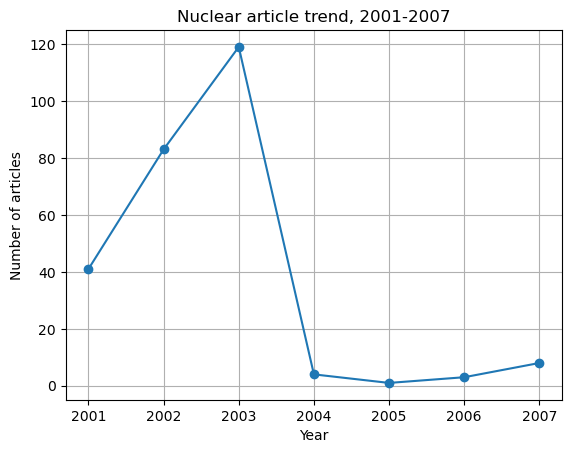

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure the index is datetime
JPnews_pd_indexed.index = pd.to_datetime(JPnews_pd_indexed.index, errors='coerce')

# filter to 2001-2007
JPnews_2001_2007 = JPnews_pd_indexed.loc['2001-01-01':'2007-12-31'].copy()

# filter nuclear articles
nuclear_articles = JPnews_2001_2007[
    JPnews_2001_2007['text'].str.contains('nuclear', case=False, na=False)
]

# count by year
trend = nuclear_articles.groupby(nuclear_articles.index.year).size()

# plot
trend.plot(kind='line', marker='o', title='Nuclear article trend, 2001-2007')
plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.grid(True)
plt.show()